In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(69)

N = 2
mu = np.random.rand(N)       # uniform [0,1], fixed for all 6400 sims
gamma = np.random.randn(N, N)  # N(0,1) i.i.d., fixed for all 6400 sims
sigma = 0.05                 # background stress, fixed

gamma_pos = np.maximum(gamma, 0)   # facilitative entries (>= 0)
gamma_neg = np.maximum(-gamma, 0)  # magnitudes of competitive entries (>= 0)

# dp_i/dt = mu_i * p_i * (1 - p_i - sigma/(1 + sum_j gamma+_ij * p_j) - sum_j gamma-_ij * p_j)
def multi_species_model(p, t, N, gamma_pos, gamma_neg, sigma, mu):
    p = np.maximum(p, 0)
    facilitation = sigma / (1 + gamma_pos @ p)  # reduced stress from positive interactions
    competition  = gamma_neg @ p                 # direct drag from negative interactions
    return mu * p * (1 - p - facilitation - competition)

print(f"mu:    {mu}")
print(f"gamma:\n{gamma}")

mu:    [0.29624916 0.80906772]
gamma:
[[ 1.16229517 -0.60140014]
 [-1.59748566  0.39772612]]


In [ ]:
time_range = np.linspace(0, 20, 30)

curves = []
initial_conditions = []

for i in np.linspace(0.01, 1.0, 80):
    for j in np.linspace(0.01, 1.0, 80):
        p0 = [i, j]
        sol = odeint(multi_species_model, p0, time_range,
                     args=(N, gamma_pos, gamma_neg, sigma, mu)).T
        curves.append(sol)           # shape (2, 30)
        initial_conditions.append(p0)

curves = np.array(curves)               # (6400, 2, 30)
initial_conditions = np.array(initial_conditions)  # (6400, 2)

print(f"Dataset shape:            {curves.shape}")
print(f"Initial conditions shape: {initial_conditions.shape}")

Dataset shape:            (6400, 2, 30)
Initial conditions shape: (6400, 2)


Train: (4800, 2, 30)  |  Test: (1600, 2, 30)


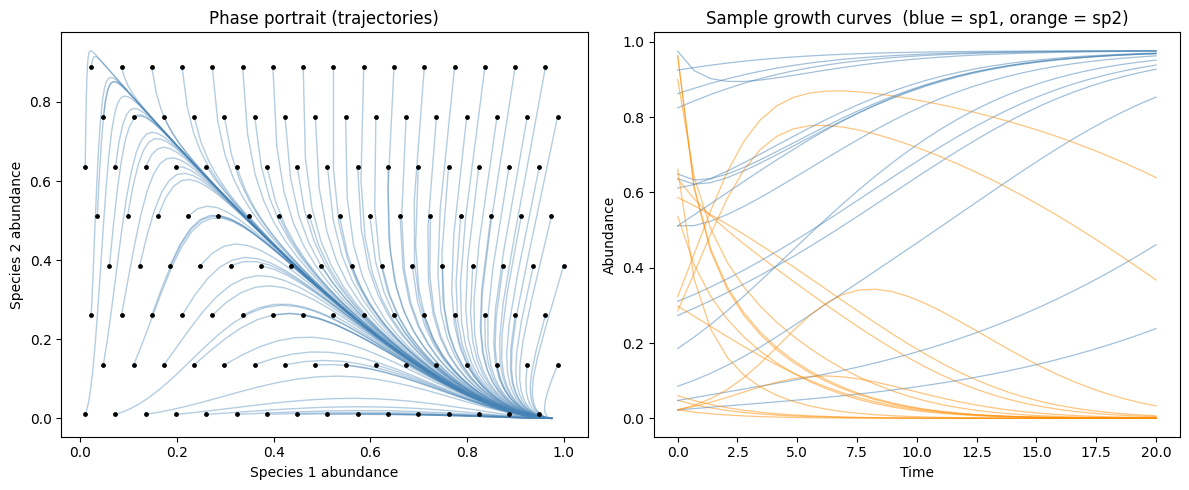

In [ ]:
# Shuffle and split: 4800 train, 1600 test
perm = np.random.permutation(6400)
train_idx, test_idx = perm[:4800], perm[4800:]

X_train  = curves[train_idx]             # (4800, 2, 30)
X_test   = curves[test_idx]              # (1600, 2, 30)
ic_train = initial_conditions[train_idx] # (4800, 2)
ic_test  = initial_conditions[test_idx]  # (1600, 2)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# --- Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Phase portrait: full trajectories p1(t) vs p2(t), one curve per initial condition
step = 50  # subsample so we draw ~128 lines, not 6400
for k in range(0, 6400, step):
    axes[0].plot(curves[k, 0, :], curves[k, 1, :],
                 color="steelblue", lw=1, alpha=0.4)
# Circles mark the initial conditions (start of each trajectory), as in the paper
axes[0].scatter(initial_conditions[::step, 0], initial_conditions[::step, 1],
                s=6, color="k", zorder=3)
axes[0].set_xlabel("Species 1 abundance")
axes[0].set_ylabel("Species 2 abundance")
axes[0].set_title("Phase portrait (trajectories)")

# Sample trajectories vs time
rng = np.random.default_rng(0)
for k in rng.integers(0, 6400, 15):
    axes[1].plot(time_range, curves[k, 0], color="steelblue", alpha=0.5, lw=0.9)
    axes[1].plot(time_range, curves[k, 1], color="darkorange", alpha=0.5, lw=0.9)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Abundance")
axes[1].set_title("Sample growth curves  (blue = sp1, orange = sp2)")

plt.tight_layout()
plt.show()

## Variational Autoencoder (E = 2)

We compress both species' full growth curves (2 x 30 = 60 values) jointly into a single
2-dimensional latent representation. The VAE regularizes the latent distribution toward a
standard isotropic Gaussian via a KL-divergence term, alongside the reconstruction (MSE) loss.
The KL weight `beta` is annealed from 0 -> 1 over the first epochs so the decoder learns good
reconstructions before the latent is pushed toward a Gaussian.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

D = 2 * 30   # input dimension (2 species x 30 time points)
E = 2        # latent dimension

# Flatten (N, 2, 30) -> (N, 60). Abundances already live in [0, 1].
Xtr = torch.tensor(X_train.reshape(len(X_train), D), dtype=torch.float32)
Xte = torch.tensor(X_test.reshape(len(X_test),  D), dtype=torch.float32)

train_loader = DataLoader(TensorDataset(Xtr), batch_size=128, shuffle=True)

print(f"Xtr: {tuple(Xtr.shape)}  |  Xte: {tuple(Xte.shape)}")

Device: cpu
Xtr: (4800, 60)  |  Xte: (1600, 60)


In [ ]:
class VAE(nn.Module):
    def __init__(self, D=60, E=2, hidden=(128, 64)):
        super().__init__()
        h1, h2 = hidden
        # Encoder: 60 -> 128 -> 64 -> (mu, logvar)
        self.enc = nn.Sequential(
            nn.Linear(D, h1), nn.LeakyReLU(),
            nn.Linear(h1, h2), nn.LeakyReLU(),
        )
        self.fc_mu     = nn.Linear(h2, E)
        self.fc_logvar = nn.Linear(h2, E)
        # Decoder: 2 -> 64 -> 128 -> 60, sigmoid keeps output in [0, 1]
        self.dec = nn.Sequential(
            nn.Linear(E, h2), nn.LeakyReLU(),
            nn.Linear(h2, h1), nn.LeakyReLU(),
            nn.Linear(h1, D), nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(x_hat, x, mu, logvar, beta):
    # Reconstruction: summed squared error per sample, averaged over the batch
    recon = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)
    # KL(N(mu, var) || N(0, I)), averaged over the batch
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon + beta * kld, recon, kld


In [ ]:
EPOCHS       = 300
ANNEAL_EPOCHS = 75   # beta ramps 0 -> 1 over these first epochs

model = VAE(D=D, E=E).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
Xtr_dev = Xtr.to(device)
Xte_dev = Xte.to(device)

history = {"loss": [], "recon": [], "kld": [], "test_recon": []}

for epoch in range(1, EPOCHS + 1):
    beta = min(1.0, epoch / ANNEAL_EPOCHS)

    model.train()
    ep_loss = ep_recon = ep_kld = 0.0
    for (xb,) in train_loader:
        xb = xb.to(device)
        opt.zero_grad()
        x_hat, mu, logvar = model(xb)
        loss, recon, kld = vae_loss(x_hat, xb, mu, logvar, beta)
        loss.backward()
        opt.step()
        ep_loss  += loss.item()  * xb.size(0)
        ep_recon += recon.item() * xb.size(0)
        ep_kld   += kld.item()   * xb.size(0)
    n = len(Xtr)
    history["loss"].append(ep_loss / n)
    history["recon"].append(ep_recon / n)
    history["kld"].append(ep_kld / n)

    # Test reconstruction (deterministic: use the mean embedding)
    model.eval()
    with torch.no_grad():
        mu_te, logvar_te = model.encode(Xte_dev)
        x_hat_te = model.decode(mu_te)
        test_recon = F.mse_loss(x_hat_te, Xte_dev, reduction="sum").item() / len(Xte)
    history["test_recon"].append(test_recon)

    if epoch % 25 == 0 or epoch == 1:
        print(f"epoch {epoch:3d} | beta {beta:.2f} | "
              f"loss {history['loss'][-1]:.4f} | recon {history['recon'][-1]:.4f} | "
              f"kld {history['kld'][-1]:.4f} | test_recon {test_recon:.4f}")

print("Done.")

In [ ]:
model.eval()
with torch.no_grad():
    mu_te, _ = model.encode(Xte_dev)
    recon_te = model.decode(mu_te).cpu().numpy().reshape(-1, 2, 30)
mu_te_np = mu_te.cpu().numpy()
X_test_np = Xte.numpy().reshape(-1, 2, 30)

# Per-sample R^2 across the whole test set
ss_res = np.sum((X_test_np - recon_te) ** 2)
ss_tot = np.sum((X_test_np - X_test_np.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"Test reconstruction R^2: {r2:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (1) Loss curves
axes[0].plot(history["recon"], label="train recon")
axes[0].plot(history["test_recon"], label="test recon")
axes[0].plot(history["kld"], label="KL", alpha=0.6)
axes[0].axvline(75, ls="--", c="gray", lw=0.8, label="anneal end")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].set_title("Training curves"); axes[0].legend(); axes[0].set_yscale("log")

# (2) Latent space, colored by initial-condition angle (relative to fixed point ~ (0.98, 0.59))
angle = np.arctan2(ic_test[:, 1] - 0.59, ic_test[:, 0] - 0.98)
sc = axes[1].scatter(mu_te_np[:, 0], mu_te_np[:, 1], c=angle, s=6, cmap="hsv")
axes[1].set_xlabel("z1"); axes[1].set_ylabel("z2")
axes[1].set_title("Latent embedding (color = IC angle)")
plt.colorbar(sc, ax=axes[1])

# (3) Reconstructed phase portrait vs ground truth
for k in range(0, len(X_test_np), 25):
    axes[2].plot(X_test_np[k, 0], X_test_np[k, 1], color="lightgray", lw=0.5)
    axes[2].plot(recon_te[k, 0],  recon_te[k, 1],  color="crimson",  lw=0.4, alpha=0.5)
axes[2].set_xlabel("Species 1 abundance"); axes[2].set_ylabel("Species 2 abundance")
axes[2].set_title("Phase portrait: truth (gray) vs reconstruction (red)")

plt.tight_layout()
plt.show()